# Steering Vectors

**Companion to** [research/09-steering-vectors.md](../research/09-steering-vectors.md)

A steering vector is a **direction** extracted from contrastive activations — usually the *mean
difference* between "has-concept" and "no-concept" examples — that you **add to the residual stream**
at inference to push the output: $a \leftarrow a + \alpha\,\hat{v}$. No training, no task data, just one
forward pass over a contrastive set (Zou et al., 2023; Rimsky et al., 2024).

**What we will see:**
1. **Difference-of-means** recovers the concept direction from contrastive activations.
2. **Activation addition** steers the behaviour as $\alpha$ grows — but inputs cross over at different $\alpha$.
3. Large $\alpha$ pushes activations **off-manifold**, where the effect becomes an artifact.
4. A raw mean-diff vector **leaks** into a correlated attribute; a clean (SAE-like) direction does not.
5. **CAA** (many pairs) gives a far more stable direction than single-pair **ActAdd**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## A synthetic latent with a known concept axis

We build a latent space where we *know* the concept direction, so we can check whether steering
recovers and uses it. There is a **concept** axis $u_c$ (the behaviour we want to steer, e.g.
"honesty"), an **off-target** axis $u_o$ (an unrelated attribute, e.g. "topic"), plus distractor
directions and noise. A fixed readout $P_c(z)=\sigma(s\,u_c^\top z)$ reports how strongly the concept
is expressed.

In [2]:
d = 40
rng = np.random.RandomState(0)
B = np.linalg.qr(rng.randn(d, d))[0]            # orthonormal basis
u_c, u_o = B[:, 0], B[:, 1]                      # concept axis, off-target axis (orthogonal)
distractors = B[:, 2:8]

def make_latent(n, concept, off_corr=0.0, seed=0):
    r = np.random.RandomState(seed)
    a_c = concept if np.ndim(concept) else concept * np.ones(n)
    a_o = off_corr * a_c + r.randn(n)            # off-target, optionally correlated with concept
    z = np.outer(a_c, u_c) + np.outer(a_o, u_o)
    z += r.randn(n, 6) @ distractors.T * 0.7     # distractor variation
    z += r.randn(n, d) * 0.25                     # isotropic noise
    return z

def P_concept(z, s=2.5):
    return 1 / (1 + np.exp(-s * (z @ u_c)))      # behaviour readout along the concept axis

print('latent ready: d =', d, '| concept axis u_c, off-target axis u_o (orthogonal)')

latent ready: d = 40 | concept axis u_c, off-target axis u_o (orthogonal)


### What you see

The construction is deliberately transparent: `u_c` is the ground-truth concept direction a steering
method should find, `u_o` lets us test for unwanted *leakage*, and `P_concept` is a fixed behaviour
meter. Because we know `u_c`, every later claim ("the steering vector points the right way", "steering
changes the behaviour", "it leaked") has an objective check.

## Experiment 1: Difference-of-means finds the concept direction

**Question:** Can a simple mean difference recover the concept axis?

We take contrastive activations — positives with concept $+2$, negatives with concept $-2$ — and
compute $v = \overline{a}_{\text{pos}} - \overline{a}_{\text{neg}}$. Then we check its alignment with
the true axis $u_c$.

In [3]:
pos = make_latent(400, concept=+2.0, seed=1)
neg = make_latent(400, concept=-2.0, seed=2)
v = pos.mean(0) - neg.mean(0)                    # steering vector (CAA difference-of-means)
v_hat = v / np.linalg.norm(v)
print(f'cos(steering vector, true concept axis u_c) = {abs(v_hat @ u_c):.3f}')
print(f'cos(steering vector, off-target axis u_o)   = {abs(v_hat @ u_o):.3f}')

cos(steering vector, true concept axis u_c) = 0.999
cos(steering vector, off-target axis u_o)   = 0.012


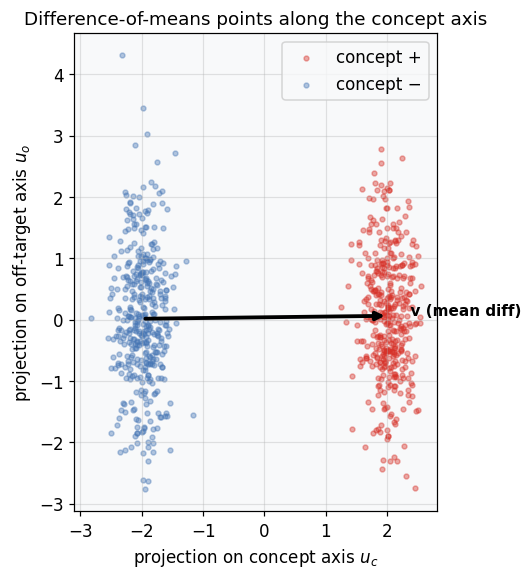

In [4]:
proj = lambda Z: np.c_[Z @ u_c, Z @ u_o]          # project onto (u_c, u_o) plane
Pp, Pn = proj(pos), proj(neg)
fig, ax = plt.subplots(figsize=(6.6, 5.4))
ax.scatter(Pp[:, 0], Pp[:, 1], s=10, c='#d73027', alpha=0.4, label='concept +')
ax.scatter(Pn[:, 0], Pn[:, 1], s=10, c='#4575b4', alpha=0.4, label='concept −')
c0 = proj(neg).mean(0)
vv = proj(v[None, :])[0]
ax.annotate('', xy=c0 + vv, xytext=c0, arrowprops=dict(arrowstyle='-|>', color='black', lw=2.5))
ax.text(*(c0 + vv * 1.05), '  v (mean diff)', fontsize=10, fontweight='bold')
ax.set_xlabel('projection on concept axis $u_c$'); ax.set_ylabel('projection on off-target axis $u_o$')
ax.set_title('Difference-of-means points along the concept axis'); ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

### What you see

The two clouds separate cleanly along the horizontal **concept axis** and overlap along the vertical
**off-target axis**. The mean-difference arrow $v$ points almost exactly horizontally — its cosine with
the true $u_c$ is ~1 and with $u_o$ is ~0. A trivial subtraction of two averages recovered the concept
direction, no training required.

That is the whole appeal of steering vectors: the direction is essentially free to extract, and (as
the next experiment shows) free to apply. It is the same kind of direction a
[linear probe](../research/01-linear-probing.md) or [CAV](../research/03-tcav.md) returns — here used to
*write* rather than *read*.

## Experiment 2: Activation addition steers — but inputs cross over at different $\alpha$

**Question:** Does adding $\alpha\hat{v}$ shift the behaviour, and is one $\alpha$ right for everyone?

We start from **neutral** inputs (concept $=0$) and sweep $\alpha$ in $a\leftarrow a+\alpha\hat{v}$,
reading $P_c$. We plot the population mean *and* a handful of individual inputs.

In [5]:
z0 = make_latent(300, concept=0.0, seed=3)
alphas = np.linspace(-3, 3, 41)
curves = np.array([P_concept(z0 + a * v_hat) for a in alphas])   # (n_alpha, n_input)
mean_curve = curves.mean(1)
# alpha at which each individual input crosses P = 0.5
cross = [alphas[np.argmin(np.abs(curves[:, i] - 0.5))] for i in range(curves.shape[1])]
print(f'alpha to reach mean P=0.5: {alphas[np.argmin(np.abs(mean_curve-0.5))]:.2f}')
print(f'per-input crossing alpha: std = {np.std(cross):.2f} (spread => no single right alpha)')

alpha to reach mean P=0.5: 0.00
per-input crossing alpha: std = 0.25 (spread => no single right alpha)


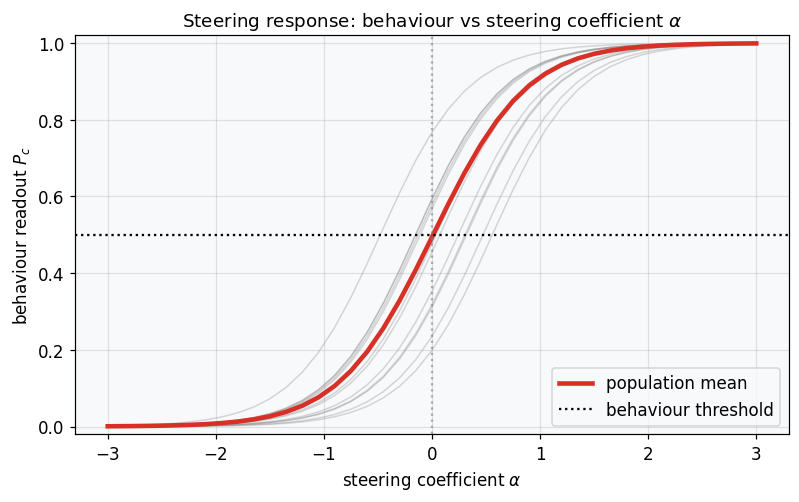

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 4.7))
for i in range(0, 300, 25):
    ax.plot(alphas, curves[:, i], color='gray', alpha=0.3, lw=1)
ax.plot(alphas, mean_curve, color='#d73027', lw=3, label='population mean')
ax.axhline(0.5, color='k', ls=':', label='behaviour threshold')
ax.axvline(0, color='gray', ls=':', alpha=0.6)
ax.set_title('Steering response: behaviour vs steering coefficient $\\alpha$')
ax.set_xlabel('steering coefficient $\\alpha$'); ax.set_ylabel('behaviour readout $P_c$')
ax.set_ylim(-0.02, 1.02); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

### What you see

The population mean (red) sweeps smoothly from $P_c\approx0$ to $\approx1$ as $\alpha$ increases —
adding the vector **does** steer the behaviour, monotonically. But the thin grey curves are individual
inputs, and they cross the threshold at **different** values of $\alpha$: an input that already leans
toward the concept needs little push, one that leans away needs a lot.

This is Rimsky et al.'s **fixed-coefficient** problem in miniature: a single $\alpha$ tuned for the
average will **over-steer** some inputs and **under-steer** others. Steering strength that fits one
context rarely fits all — a core reason steering is fiddly in practice.

## Experiment 3 (limitation): large $\alpha$ goes off-manifold

**Question:** Can we just crank $\alpha$ to force the behaviour?

Pushing hard moves activations into regions the data never occupies. We track the behaviour readout
**and** the Mahalanobis distance of the steered latent to the data distribution as $\alpha$ grows.

In [7]:
Zdata = make_latent(4000, concept=rng.randn(4000), off_corr=0.0, seed=9)
mu = Zdata.mean(0); cov = np.cov(Zdata, rowvar=False) + 1e-3 * np.eye(d); cov_inv = np.linalg.inv(cov)
def mahal(Z):
    D = Z - mu
    return np.sqrt(np.einsum('ij,jk,ik->i', D, cov_inv, D))

z0 = make_latent(300, concept=0.0, seed=3)
big_alphas = np.linspace(0, 12, 31)
beh = [P_concept(z0 + a * v_hat).mean() for a in big_alphas]
md_dist = [mahal(z0 + a * v_hat).mean() for a in big_alphas]
typical = np.percentile(mahal(Zdata), 99)
print(f'99th-percentile in-distribution Mahalanobis = {typical:.1f}')

99th-percentile in-distribution Mahalanobis = 8.0


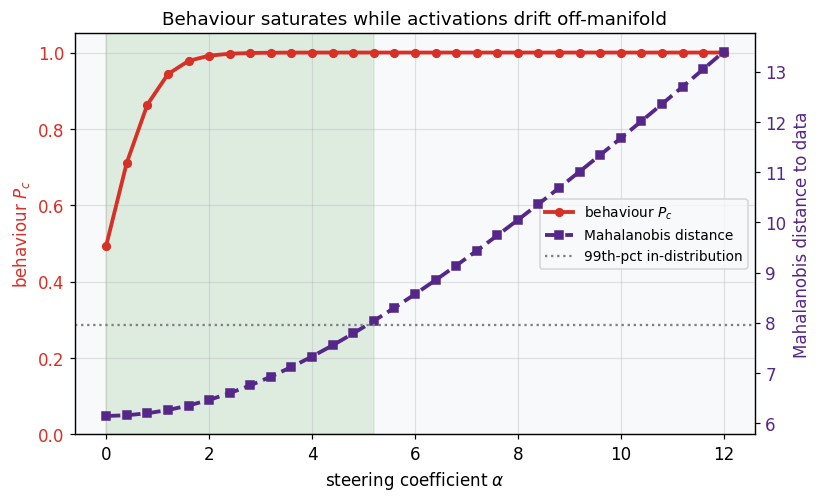

In [8]:
fig, ax1 = plt.subplots(figsize=(7.6, 4.7))
ax1.plot(big_alphas, beh, 'o-', color='#d73027', lw=2.5, ms=5, label='behaviour $P_c$')
ax1.set_xlabel('steering coefficient $\\alpha$'); ax1.set_ylabel('behaviour $P_c$', color='#d73027')
ax1.tick_params(axis='y', labelcolor='#d73027'); ax1.set_ylim(0, 1.05)
ax2 = ax1.twinx()
ax2.plot(big_alphas, md_dist, 's--', color='#542788', lw=2.5, ms=5, label='Mahalanobis distance')
ax2.axhline(typical, color='gray', ls=':', label='99th-pct in-distribution')
ax2.set_ylabel('Mahalanobis distance to data', color='#542788'); ax2.tick_params(axis='y', labelcolor='#542788')
ax2.grid(False)
a_on = big_alphas[np.argmin(np.abs(np.array(md_dist) - typical))]
ax1.axvspan(0, a_on, color='green', alpha=0.10)
ax1.set_title('Behaviour saturates while activations drift off-manifold')
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='center right', fontsize=9)
plt.tight_layout(); plt.show()

### What you see

Inside the green band the behaviour climbs and the Mahalanobis distance stays in the normal range —
steering is **on-manifold** and meaningful. Past it, $P_c$ has already saturated near 1, but the
Mahalanobis distance keeps climbing without bound: the steered latent is now a point no real input
ever produces.

In a real model this off-manifold regime is where **generation collapses** — repeated tokens,
incoherent text — even though the behaviour meter reads "maxed out". There is only a narrow $\alpha$
window between *too weak* and *broken*, the same off-manifold limit the
[causal-intervention note](../research/04-causal-intervention-vs-observational.md) flags for any latent
edit.

## Experiment 4 (limitation): mean-diff leaks; a clean direction does not

**Question:** Does steering the concept also move *unrelated* attributes?

If the calibration data correlates the concept with an off-target attribute, the mean-difference vector
absorbs that correlation and **leaks**. We build a correlated calibration set, extract the mean-diff
vector, and compare steering with it versus steering with a clean (SAE-like, isolated) direction —
measuring the change in both the target and the off-target attribute.

In [9]:
# calibration where off-target is correlated with the concept (rho=0.6)
pos_c = make_latent(400, concept=+2.0, off_corr=0.6, seed=11)
neg_c = make_latent(400, concept=-2.0, off_corr=0.6, seed=12)
v_leak = pos_c.mean(0) - neg_c.mean(0); v_leak /= np.linalg.norm(v_leak)   # entangled mean-diff
v_clean = u_c.copy()                                                       # isolated (SAE-like) direction

z0 = make_latent(300, concept=0.0, seed=3)
def deltas(direction, a=2.0):
    z1 = z0 + a * direction
    return (z1 @ u_c - z0 @ u_c).mean(), (z1 @ u_o - z0 @ u_o).mean()      # Δtarget, Δoff-target

dt_leak, do_leak = deltas(v_leak)
dt_clean, do_clean = deltas(v_clean)
print(f'mean-diff : Δconcept={dt_leak:+.2f}  Δoff-target={do_leak:+.2f}')
print(f'clean dir : Δconcept={dt_clean:+.2f}  Δoff-target={do_clean:+.2f}')

mean-diff : Δconcept=+1.69  Δoff-target=+1.06
clean dir : Δconcept=+2.00  Δoff-target=+0.00


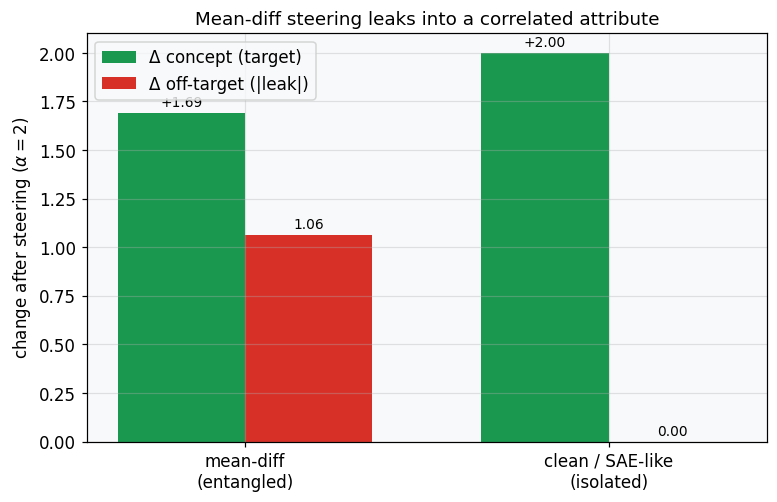

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 4.7))
x = np.arange(2); w = 0.35
ax.bar(x - w / 2, [dt_leak, dt_clean], w, label='Δ concept (target)', color='#1a9850')
ax.bar(x + w / 2, [abs(do_leak), abs(do_clean)], w, label='Δ off-target (|leak|)', color='#d73027')
for i, (t, o) in enumerate([(dt_leak, do_leak), (dt_clean, do_clean)]):
    ax.annotate(f'{t:+.2f}', (i - w / 2, t), textcoords='offset points', xytext=(0, 4), ha='center', fontsize=9)
    ax.annotate(f'{abs(o):.2f}', (i + w / 2, abs(o)), textcoords='offset points', xytext=(0, 4), ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(['mean-diff\n(entangled)', 'clean / SAE-like\n(isolated)'])
ax.set_ylabel('change after steering ($\\alpha=2$)')
ax.set_title('Mean-diff steering leaks into a correlated attribute')
ax.legend()
plt.tight_layout(); plt.show()

### What you see

The **clean** direction puts its *entire* push into the target concept ($\Delta\approx2.0$) with
**zero** off-target change. The entangled **mean-diff** vector does two bad things at once: it diverts a
large chunk of its push into the **off-target** attribute ($\Delta\approx1.06$ — the leak) and, because
that budget is spent sideways, moves the **target less** ($\Delta\approx1.69$).

This is the [superposition](../research/06-superposition-hypothesis.md) caveat at work: a raw
mean-difference is only as disentangled as its calibration set, and correlated concepts leak. It is why
the note recommends sourcing steering directions from **mono-semantic SAE features** when a clean,
side-effect-free edit matters.

## Experiment 5: CAA (many pairs) vs ActAdd (single pair)

**Question:** Why average over many contrastive pairs instead of using one?

A single prompt pair (ActAdd) gives a noisy direction; averaging many pairs (CAA) cancels the noise.
We extract the steering vector from $n$ contrastive pairs, repeat across resamples, and measure how
well — and how *consistently* — it aligns with the true concept axis.

In [11]:
ns = [1, 2, 4, 8, 16, 32, 64, 128]
mean_align, std_align = [], []
for n in ns:
    cs = []
    for rep in range(40):
        p = make_latent(n, concept=+2.0, seed=1000 + rep)
        q = make_latent(n, concept=-2.0, seed=5000 + rep)
        vv = p.mean(0) - q.mean(0); vv /= np.linalg.norm(vv)
        cs.append(abs(vv @ u_c))
    mean_align.append(np.mean(cs)); std_align.append(np.std(cs))
mean_align, std_align = np.array(mean_align), np.array(std_align)
print('pairs:', ns)
print('mean alignment:', np.round(mean_align, 3))

pairs: [1, 2, 4, 8, 16, 32, 64, 128]
mean alignment: [0.752 0.85  0.911 0.948 0.973 0.986 0.993 0.997]


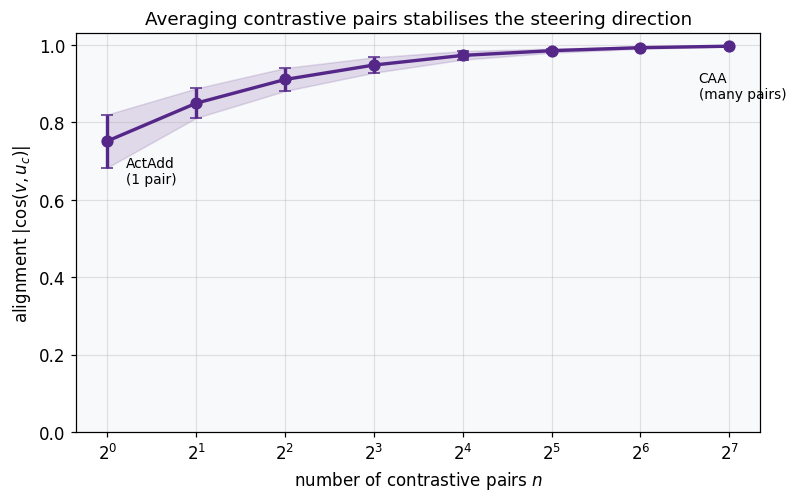

In [12]:
fig, ax = plt.subplots(figsize=(7.4, 4.7))
ax.errorbar(ns, mean_align, yerr=std_align, fmt='o-', color='#542788', lw=2.2, ms=7, capsize=4)
ax.fill_between(ns, mean_align - std_align, mean_align + std_align, color='#542788', alpha=0.15)
ax.set_xscale('log', base=2)
ax.annotate('ActAdd\n(1 pair)', (ns[0], mean_align[0]), textcoords='offset points', xytext=(12, -28), fontsize=9)
ax.annotate('CAA\n(many pairs)', (ns[-1], mean_align[-1]), textcoords='offset points', xytext=(-20, -34), fontsize=9)
ax.set_title('Averaging contrastive pairs stabilises the steering direction')
ax.set_xlabel('number of contrastive pairs $n$'); ax.set_ylabel('alignment $|\\cos(v, u_c)|$')
ax.set_ylim(0, 1.03)
plt.tight_layout(); plt.show()

### What you see

With a single pair (ActAdd, left) the alignment is **markedly lower and highly variable** (~0.75 with a
wide spread) — one contrastive example is dominated by per-example noise, so the direction is
unreliable. As the number of pairs grows, alignment rises toward 1 and its spread collapses: averaging
cancels the idiosyncratic noise and leaves the shared concept direction.

This is why **CAA** averages many pairs rather than relying on one: the mean difference is a noisy
estimator of the concept axis, and $n$ pairs cut its variance by $\sim\!1/\sqrt{n}$. The cost is just a
larger calibration set — still no training.

## Summary / Key Takeaways

- **Exp 1** — A **difference-of-means** of contrastive activations recovers the concept axis ($\cos\approx1$)
  with no training — the same kind of direction a probe/CAV returns, used to *write*.
- **Exp 2** — **Activation addition** steers the behaviour monotonically, but individual inputs cross over
  at different $\alpha$: one fixed coefficient over-/under-steers (Rimsky et al.).
- **Exp 3** — Large $\alpha$ drives activations **off-manifold** (Mahalanobis explodes) where real models
  collapse — only a narrow usable window.
- **Exp 4** — A raw mean-diff vector **leaks** into attributes correlated in its calibration set; a clean
  (SAE-like) direction does not — prefer mono-semantic sources.
- **Exp 5** — **CAA** (many pairs) yields a stable direction; single-pair **ActAdd** is noisy — averaging
  cuts variance by $\sim\!1/\sqrt{n}$.
